In [1]:
# 1. Install libraries but tell pip NOT to update existing core packages like numpy/pandas
!pip install yfinance pandas-ta plotly --no-deps -q

import yfinance as yf
import pandas as pd
import numpy as np

# Apply the fix for pandas-ta compatibility
try:
    pd.Timestamp.day_name = lambda self: self.strftime('%A')
    pd.Timestamp.month_name = lambda self: self.strftime('%B')
except:
    pass

import pandas_ta as ta
import plotly.graph_objects as go
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("✅ Step 1: Environment successfully stabilized using --no-deps.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 3.2 MB/s eta 0:00:00
✅ Step 1: Environment successfully stabilized using --no-deps.


In [2]:
# 1. Download Historical Data for NVIDIA
ticker = "NVDA"
df = yf.download(ticker, start="2018-01-01", end="2026-01-01")

# --- THE COLUMN FIX ---
# yfinance sometimes returns MultiIndex columns (e.g., ('Close', 'NVDA'))
# This flattens them so the rest of our code can find 'Close', 'High', etc.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Add Technical Indicators (Feature Engineering)
# RSI: Measures if a stock is overbought (>70) or oversold (<30)
df['RSI'] = ta.rsi(df['Close'], length=14)

# EMA: Exponential Moving Averages to identify the trend
df['EMA_20'] = ta.ema(df['Close'], length=20)
df['EMA_50'] = ta.ema(df['Close'], length=50)

# ATR: Average True Range to measure market volatility
df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

# 3. Create the Target (The thing we want to predict)
# We want to predict if TOMORROW'S price is higher than TODAY'S price.
# 1 = Price Up, 0 = Price Down/Flat
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 4. Data Cleaning
# Indicators like EMA_50 need 50 days of data to start calculating, so we drop the empty rows.
df.dropna(inplace=True)

# Define our Final Features (X) and Label (y)
features = ['Close', 'RSI', 'EMA_20', 'EMA_50', 'ATR']
X = df[features]
y = df['Target']

print(f"✅ Step 2 Complete! Dataset ready with {len(X)} rows.")
df.tail(3)

/tmp/ipykernel_1063/3295002369.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

✅ Step 2 Complete! Dataset ready with 1962 rows.


Price,Close,High,Low,Open,Volume,RSI,EMA_20,EMA_50,ATR,Target
Date,,,,,,,,,,
2025-12-29,188.209808,188.749772,185.899936,187.699841,120006100,55.684287,183.380007,183.418166,5.639128,0
2025-12-30,187.529846,188.979780,186.919879,188.229821,97687300,54.796052,183.775230,183.579409,5.383469,0
2025-12-31,186.489914,190.549692,186.479920,189.559755,120100500,53.393281,184.033771,183.693546,5.289633,0


In [3]:
# 1. Initialize the TimeSeriesSplit (Professional approach for Finance)
tscv = TimeSeriesSplit(n_splits=5)

# 2. Initialize the Model
# We use 'balanced' class weights because 'Price Up' and 'Price Down' days
# might not be equal, and we want the model to pay attention to both.
model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=50,
    class_weight='balanced',
    random_state=42
)

# 3. Train using the splits
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model_tuned.fit(X_train, y_train)

# 4. Generate Predictions and Report
tuned_predictions = model_tuned.predict(X_test)

print("--- AI Model Performance Report ---")
print(classification_report(y_test, tuned_predictions))

--- AI Model Performance Report ---
              precision    recall  f1-score   support

           0       0.47      0.91      0.62       153
           1       0.53      0.09      0.16       174

    accuracy                           0.47       327
   macro avg       0.50      0.50      0.39       327
weighted avg       0.50      0.47      0.37       327



In [4]:
# 1. Create a copy of the test data for backtesting
backtest_df = X_test.copy()
backtest_df['Actual_Next_Day_Up'] = y_test
backtest_df['Model_Prediction'] = tuned_predictions

# 2. Calculate the Daily Returns of the Market
# We use the 'Close' price pct_change to see how much the stock moved daily
backtest_df['Market_Returns'] = backtest_df['Close'].pct_change()

# 3. Calculate Strategy Returns
# If the model predicted 1 (Up), we 'buy' and get the market return.
# If it predicted 0, we stay in cash (0% return).
# Note: We shift the prediction by 1 because today's prediction affects tomorrow's return.
backtest_df['Strategy_Returns'] = backtest_df['Market_Returns'] * backtest_df['Model_Prediction'].shift(1)

# 4. Calculate Cumulative Growth of $1
backtest_df['Cumulative_Market'] = (1 + backtest_df['Market_Returns'].fillna(0)).cumprod()
backtest_df['Cumulative_Strategy'] = (1 + backtest_df['Strategy_Returns'].fillna(0)).cumprod()

# 5. Professional Visualization with Plotly
fig = go.Figure()

# Market Line
fig.add_trace(go.Scatter(x=backtest_df.index, y=backtest_df['Cumulative_Market'],
                         name='Buy & Hold (Market)', line=dict(color='gray', dash='dash')))

# AI Strategy Line
fig.add_trace(go.Scatter(x=backtest_df.index, y=backtest_df['Cumulative_Strategy'],
                         name='AI Strategy', line=dict(color='green', width=3)))

fig.update_layout(title='AI Strategy vs. Market Returns (NVDA)',
                  xaxis_title='Date', yaxis_title='Growth of $1 Investment',
                  template='plotly_white', hovermode="x unified")
fig.show()

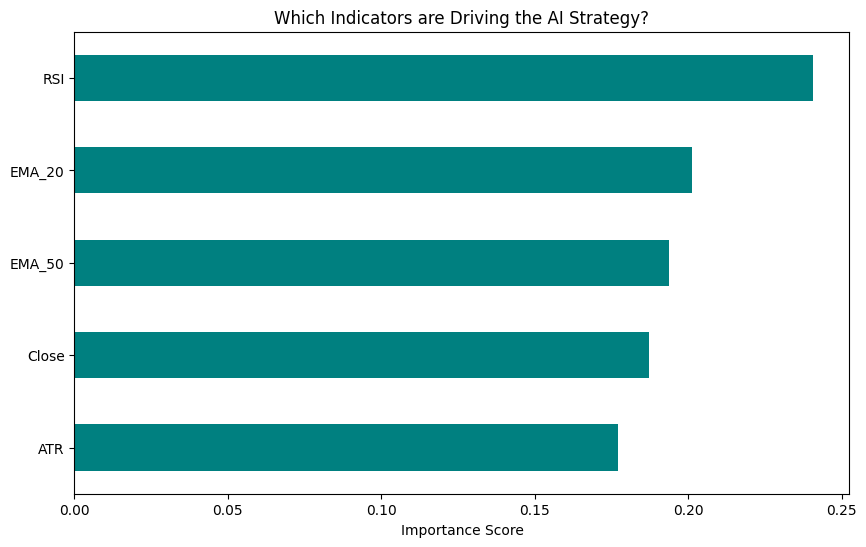

In [5]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importances = model_tuned.feature_importances_
feat_importances = pd.Series(importances, index=features)

# Plot
plt.figure(figsize=(10, 6))
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Which Indicators are Driving the AI Strategy?')
plt.xlabel('Importance Score')
plt.show()

In [6]:
!pip install gradio -q
import gradio as gr

In [7]:
def predict_stock_movement(ticker):
    try:
        # 1. Fetch live data (Last 100 days to ensure indicators like EMA_50 have enough data)
        ticker = ticker.upper().strip()
        data = yf.download(ticker, period="100d", interval="1d", progress=False)

        if data.empty:
            return "❌ Error: Ticker not found. Please use symbols like AAPL, TSLA, or NVDA."

        # Flatten MultiIndex columns (Fix for newest yfinance)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # 2. Calculate Indicators (Must match your training features exactly)
        data['RSI'] = ta.rsi(data['Close'], length=14)
        data['EMA_20'] = ta.ema(data['Close'], length=20)
        data['EMA_50'] = ta.ema(data['Close'], length=50)
        data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)

        # 3. Get the most recent row for prediction
        latest_data = data[['Close', 'RSI', 'EMA_20', 'EMA_50', 'ATR']].tail(1)

        if latest_data.isnull().values.any():
            return "⏳ Data loading... Please try a major stock with more history."

        # 4. Make Prediction using your 'model_tuned'
        prediction = model_tuned.predict(latest_data)[0]
        probability = model_tuned.predict_proba(latest_data)[0]

        # 5. Format Output
        direction = "🚀 BULLISH (Upward Trend Predicted)" if prediction == 1 else "📉 BEARISH (Downward Trend Predicted)"
        confidence = f"Model Confidence: {max(probability)*100:.2f}%"

        return f"{direction}\n{confidence}"

    except Exception as e:
        return f"⚠️ System Error: {str(e)}"

In [8]:
# Create the Gradio Interface
demo = gr.Interface(
    fn=predict_stock_movement,
    inputs=gr.Textbox(label="Stock Ticker Symbol", placeholder="e.g. NVDA, AAPL, MSFT"),
    outputs=gr.Textbox(label="AI Analysis for Next Trading Day"),
    title="🤖 AI Stock Market Signal Generator",
    description="This application uses a Random Forest Classifier trained on technical indicators (RSI, EMA, ATR) to predict next-day price movement.",
    theme="glass", # A sleek, modern theme for your portfolio
    examples=["NVDA", "TSLA", "AAPL", "BTC-USD"] # BTC-USD shows it works for Crypto too!
)

# share=True creates a public link you can send to anyone for 72 hours
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14b47bac62243c0905.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
import joblib

# This saves your trained model to a file
joblib.dump(model_tuned, 'model.joblib')

# This downloads it to your computer
from google.colab import files
files.download('model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
requirements = """
yfinance
pandas-ta
scikit-learn
gradio
numpy<2.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
app_code = """
import gradio as gr
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import joblib

# Load the saved model
model = joblib.load('model.joblib')

# Patch for pandas-ta
pd.Timestamp.day_name = lambda self: self.strftime('%A')
pd.Timestamp.month_name = lambda self: self.strftime('%B')

def predict_stock(ticker):
    try:
        ticker = ticker.upper().strip()
        data = yf.download(ticker, period="100d", interval="1d", progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data['RSI'] = ta.rsi(data['Close'], length=14)
        data['EMA_20'] = ta.ema(data['Close'], length=20)
        data['EMA_50'] = ta.ema(data['Close'], length=50)
        data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)

        features = ['Close', 'RSI', 'EMA_20', 'EMA_50', 'ATR']
        latest_data = data[features].tail(1)

        prediction = model.predict(latest_data)[0]
        prob = model.predict_proba(latest_data)[0]

        res = "🚀 BULLISH" if prediction == 1 else "📉 BEARISH"
        return f"{res} (Confidence: {max(prob)*100:.2f}%)"
    except Exception as e:
        return str(e)

demo = gr.Interface(fn=predict_stock, inputs="text", outputs="text", title="Stock AI")
demo.launch()
"""

with open("app.py", "w") as f:
    f.write(app_code)

files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>